## Task 3: Model Training

## Overview

This notebook trains five models in order of increasing complexity, tunes the best-performing ones with Optuna, and selects the champion model based on validation metrics.

### Model progression

| Model | Why we train it | Key concept learned |
|---|---|---|
| Logistic Regression | Interpretable baseline — coefficients are odds ratios | Linear decision boundary |
| Decision Tree | Visual baseline — shows learned rules explicitly | Non-linear splits, overfitting |
| Random Forest | Bagging ensemble — robust, parallel | Variance reduction via averaging |
| XGBoost | Boosting ensemble — typically highest AUC | Sequential error correction |
| LightGBM | Speed-optimized boosting — 10x faster | Histogram-based splits |

### Evaluation metrics

**Why we use PR-AUC as primary metric, not ROC-AUC:**

ROC-AUC measures ranking quality across all classification thresholds. On imbalanced data (11.6% positives), a model can achieve ROC-AUC > 0.85 while being nearly useless at identifying the minority class — because the large majority class dominates the curve. PR-AUC focuses specifically on the minority class: at every recall level, how precise are we? This is the metric that matters for a bank deciding whether to approve or reject a loan.

**KS Statistic:** The Kolmogorov-Smirnov statistic measures the maximum separation between the cumulative distribution of predicted scores for defaulters vs non-defaulters. This is what credit risk teams report to management. A KS of 0.3 is considered acceptable, 0.4 is good, 0.5+ is excellent.

### Success metrics

| Metric | Minimum target | Good |
|---|---|---|
| Validation ROC-AUC | > 0.75 | > 0.85 |
| Validation PR-AUC | > 0.35 | > 0.50 |
| KS Statistic | > 0.25 | > 0.40 |
| F1 (optimal threshold) | > 0.35 | > 0.45 |

---
## Step 1 — Install and Import

### Why Optuna instead of GridSearchCV

`GridSearchCV` tries every combination in a predefined grid — 5 values × 5 values × 5 values = 125 fits, each costing 30 seconds = 62 minutes. Most combinations are poor and waste time.

Optuna uses **Tree-structured Parzen Estimator (TPE)** — a Bayesian optimization algorithm that builds a probabilistic model of which hyperparameter regions produce good results, then samples the next trial from the most promising region. This finds better hyperparameters in 30 trials than GridSearchCV finds in 125.

In [2]:
!pip install optuna lightgbm xgboost -q

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, confusion_matrix,
    classification_report, precision_score, recall_score
)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)

OUTPUT_DIR = Path('/content/loan_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'XGBoost  : {xgb.__version__}')
print(f'LightGBM : {lgb.__version__}')
print(f'Optuna   : {optuna.__version__}')

XGBoost  : 3.1.3
LightGBM : 4.6.0
Optuna   : 4.8.0


---
## Step 2 — Load Splits


In [3]:
!ls "/content/loan_outputs"

all_models.pkl
champion_model.pkl
champion_threshold.txt
df_eda.csv
eda_summary.csv
feature_engineering_validation.png
features_manifest.csv
final_feature_correlations.png
final_test_evaluation.png
ks_plot.png
model_card.txt
model_comparison.png
model_results.csv
pr_curves.png
roc_curves.png
scaler.pkl
shap_dependence_plots.png
shap_importance_bar.png
shap_local_explanation.png
shap_summary_beeswarm.png
test_confusion_matrix_LogisticRegression.png
test_pr_curve_LogisticRegression.png
test_roc_curve_LogisticRegression.png
threshold_optimization.png
val_probs.json
X_test.csv
X_test_lr.csv
X_train.csv
X_train_lr.csv
X_val.csv
X_val_lr.csv
y_test.csv
y_train.csv
y_val.csv


In [4]:
# Tree model splits (unscaled)
X_train = pd.read_csv(OUTPUT_DIR / 'X_train.csv')
X_val   = pd.read_csv(OUTPUT_DIR / 'X_val.csv')
y_train = pd.read_csv(OUTPUT_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(OUTPUT_DIR / 'y_val.csv').squeeze()

# LR splits (scaled)
X_train_lr = pd.read_csv(OUTPUT_DIR / 'X_train_lr.csv')
X_val_lr   = pd.read_csv(OUTPUT_DIR / 'X_val_lr.csv')

TARGET     = 'Default'
SPW        = round(y_train.value_counts()[0] / y_train.value_counts()[1], 1)
FEAT_COLS  = X_train.columns.tolist()

print(f'Train : {X_train.shape[0]:,} rows x {X_train.shape[1]} features')
print(f'Val   : {X_val.shape[0]:,} rows x {X_val.shape[1]} features')
print(f'scale_pos_weight: {SPW}')
print(f'Default rate train: {y_train.mean()*100:.1f}%')

Train : 178,742 rows x 34 features
Val   : 38,302 rows x 34 features
scale_pos_weight: 7.6
Default rate train: 11.6%


---
## Step 3 — Evaluation Helper Functions

### The metric suite we report for every model

We compute six metrics consistently for every model. Together they give a complete picture that no single metric provides alone.

```
ROC-AUC    → overall ranking quality (threshold-independent)
PR-AUC     → minority class detection quality (threshold-independent)
KS Stat    → max separation between score distributions (credit industry standard)
F1 @ opt   → performance at the threshold that maximizes F1
Precision  → of loans we flag as risky, what fraction truly default
Recall     → of all true defaults, what fraction do we catch
```

The KS statistic is computed as:
```
KS = max(TPR - FPR) across all thresholds
```
Equivalently: the maximum vertical distance between the default score CDF and the non-default score CDF.

In [5]:
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

def optimal_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    best_idx  = np.argmax(f1_scores[:-1])
    return float(thresholds[best_idx]), float(f1_scores[best_idx])

def evaluate(name, model, X_tr, X_vl, y_tr, y_vl):
    t0 = time.time()
    if hasattr(model, 'predict_proba'):
        train_prob = model.predict_proba(X_tr)[:, 1]
        val_prob   = model.predict_proba(X_vl)[:, 1]
    else:
        train_prob = model.decision_function(X_tr)
        val_prob   = model.decision_function(X_vl)

    thresh, _ = optimal_threshold(y_vl, val_prob)
    val_pred  = (val_prob >= thresh).astype(int)

    metrics = {
        'model':           name,
        'train_auc':       round(roc_auc_score(y_tr, train_prob), 4),
        'val_auc':         round(roc_auc_score(y_vl, val_prob),   4),
        'val_pr_auc':      round(average_precision_score(y_vl, val_prob), 4),
        'val_ks':          round(ks_statistic(y_vl, val_prob),    4),
        'val_f1':          round(f1_score(y_vl, val_pred),        4),
        'val_precision':   round(precision_score(y_vl, val_pred), 4),
        'val_recall':      round(recall_score(y_vl, val_pred),    4),
        'opt_threshold':   round(thresh, 4),
        'train_time_s':    round(time.time() - t0, 1),
        'overfit_gap':     round(roc_auc_score(y_tr, train_prob) -
                                 roc_auc_score(y_vl, val_prob), 4),
    }
    print(f"  {name:<25} val_AUC={metrics['val_auc']:.4f}  "
          f"PR-AUC={metrics['val_pr_auc']:.4f}  "
          f"KS={metrics['val_ks']:.4f}  "
          f"F1={metrics['val_f1']:.4f}  "
          f"overfit={metrics['overfit_gap']:+.4f}")
    return metrics, val_prob

results    = []
val_probs  = {}
models     = {}
print('Model evaluation tracker initialized.')

Model evaluation tracker initialized.


---
## Model 1: Logistic Regression Baseline

### What Logistic Regression actually does

Logistic Regression models the log-odds of default as a linear combination of features:

```
log(P(default) / P(no default)) = b0 + b1*InterestRate + b2*Age + ... + bn*loan_to_income
```

The coefficient `b1` for `InterestRate` means: a one-standard-deviation increase in `InterestRate` multiplies the odds of default by `exp(b1)`. This is directly interpretable as an odds ratio — which is why Logistic Regression is the model regulators require for credit scoring in many jurisdictions.

### Why class_weight='balanced' matters here

Without `class_weight='balanced'`, the loss function weighs each sample equally. With 88.4% non-defaults, the model minimizes loss by predicting "no default" for everything — achieving 88.4% accuracy while being completely useless. `class_weight='balanced'` automatically sets sample weights inversely proportional to class frequency, forcing the model to treat each default as 7.6× more important than each non-default during training.

In [6]:
print('Training Logistic Regression...')

lr_model = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_lr, y_train)

m, vp = evaluate('Logistic Regression', lr_model,
                  X_train_lr, X_val_lr, y_train, y_val)
results.append(m)
val_probs['Logistic Regression'] = vp
models['Logistic Regression'] = lr_model

# Show top coefficients (odds ratios)
coef_df = pd.DataFrame({
    'feature': FEAT_COLS,
    'coef':    lr_model.coef_[0],
    'odds_ratio': np.exp(lr_model.coef_[0])
}).sort_values('coef', key=abs, ascending=False).head(15)

print('\nTop 15 features by coefficient magnitude (odds ratios):')
print(f'  {"Feature":<40} {"Coef":>8}  {"Odds Ratio":>12}')
print('  ' + '-'*62)
for _, row in coef_df.iterrows():
    direction = 'INCREASES default risk' if row['coef'] > 0 else 'DECREASES default risk'
    print(f"  {row['feature']:<40} {row['coef']:>8.4f}  {row['odds_ratio']:>12.4f}  [{direction}]")

Training Logistic Regression...
  Logistic Regression       val_AUC=0.7589  PR-AUC=0.3339  KS=0.3843  F1=0.3718  overfit=-0.0038

Top 15 features by coefficient magnitude (odds ratios):
  Feature                                      Coef    Odds Ratio
  --------------------------------------------------------------
  Age                                       -0.5286        0.5895  [DECREASES default risk]
  InterestRate                               0.4845        1.6234  [INCREASES default risk]
  loan_to_income                             0.4635        1.5896  [INCREASES default risk]
  MonthsEmployed                            -0.3285        0.7200  [DECREASES default risk]
  EmploymentType_Unemployed                  0.1903        1.2097  [INCREASES default risk]
  HasCoSigner                               -0.1292        0.8788  [DECREASES default risk]
  CreditScore                               -0.1290        0.8790  [DECREASES default risk]
  HasDependents                        

---
## Model 2: Decision Tree Baseline


In [7]:
print('Training Decision Tree...')

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)

m, vp = evaluate('Decision Tree (d=5)', dt_model,
                  X_train, X_val, y_train, y_val)
results.append(m)
val_probs['Decision Tree (d=5)'] = vp
models['Decision Tree (d=5)'] = dt_model

# Feature importance
feat_imp = pd.Series(
    dt_model.feature_importances_, index=FEAT_COLS
).sort_values(ascending=False).head(10)

print('\nTop 10 features (Decision Tree importance):')
for feat, imp in feat_imp.items():
    bar = '#' * int(imp * 200)
    print(f'  {feat:<40} {imp:.4f}  {bar}')

Training Decision Tree...
  Decision Tree (d=5)       val_AUC=0.7235  PR-AUC=0.2713  KS=0.3309  F1=0.3421  overfit=+0.0001

Top 10 features (Decision Tree importance):
  Age                                      0.3908  ##############################################################################
  loan_to_income                           0.2808  ########################################################
  InterestRate                             0.2234  ############################################
  MonthsEmployed                           0.1050  ####################
  Income                                   0.0000  
  CreditScore                              0.0000  
  NumCreditLines                           0.0000  
  LoanTerm                                 0.0000  
  DTIRatio                                 0.0000  
  LoanAmount                               0.0000  


---
## Model 3: Random Forest


In [8]:
print('Training Random Forest (this takes 2-3 minutes on CPU)...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

m, vp = evaluate('Random Forest', rf_model,
                  X_train, X_val, y_train, y_val)
results.append(m)
val_probs['Random Forest'] = vp
models['Random Forest'] = rf_model

feat_imp_rf = pd.Series(
    rf_model.feature_importances_, index=FEAT_COLS
).sort_values(ascending=False).head(10)

print('\nTop 10 features (Random Forest importance):')
for feat, imp in feat_imp_rf.items():
    bar = '#' * int(imp * 200)
    print(f'  {feat:<40} {imp:.4f}  {bar}')

Training Random Forest (this takes 2-3 minutes on CPU)...
  Random Forest             val_AUC=0.7501  PR-AUC=0.3197  KS=0.3686  F1=0.3612  overfit=+0.0581

Top 10 features (Random Forest importance):
  Age                                      0.1618  ################################
  InterestRate                             0.1299  #########################
  loan_to_income                           0.1216  ########################
  age_risk_segment_mature                  0.0810  ################
  Income                                   0.0806  ################
  MonthsEmployed                           0.0629  ############
  interest_burden                          0.0604  ############
  monthly_payment_proxy                    0.0503  ##########
  LoanAmount                               0.0462  #########
  CreditScore                              0.0324  ######


---
## Model 4: XGBoost with Optuna Tuning


In [9]:
print('Running Optuna hyperparameter search for XGBoost (30 trials)...')

def xgb_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 100, 500),
        'max_depth':          trial.suggest_int('max_depth', 3, 8),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 20),
        'scale_pos_weight':   SPW,
        # early_stopping_rounds moved to constructor in XGBoost 2.x
        'early_stopping_rounds': 20,
        'eval_metric':        'aucpr',
        'random_state':       42,
        'n_jobs':             -1,
        'verbosity':          0,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    y_prob = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_prob)

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest PR-AUC (validation): {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

# Refit final model without early_stopping (fixed n_estimators from best trial)
best_params_clean = {k: v for k, v in study_xgb.best_params.items()}
best_xgb = xgb.XGBClassifier(
    **best_params_clean,
    scale_pos_weight=SPW,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
best_xgb.fit(X_train, y_train)

m, vp = evaluate('XGBoost (tuned)', best_xgb,
                  X_train, X_val, y_train, y_val)
results.append(m)
val_probs['XGBoost (tuned)'] = vp
models['XGBoost (tuned)'] = best_xgb

Running Optuna hyperparameter search for XGBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best PR-AUC (validation): 0.3327
Best params: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.028322797738849766, 'subsample': 0.6662225125541512, 'colsample_bytree': 0.8896251144197835, 'reg_alpha': 0.10779883287765607, 'reg_lambda': 1.5758446808255544, 'min_child_weight': 16}
  XGBoost (tuned)           val_AUC=0.7573  PR-AUC=0.3327  KS=0.3816  F1=0.3724  overfit=+0.0049


---
## Model 5: LightGBM with Optuna Tuning


In [10]:
print('Running Optuna hyperparameter search for LightGBM (30 trials)...')

def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'scale_pos_weight':  SPW,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(20, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    y_prob = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_prob)

study_lgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_lgb.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest PR-AUC (validation): {study_lgb.best_value:.4f}')
print(f'Best params: {study_lgb.best_params}')

best_lgb = lgb.LGBMClassifier(
    **study_lgb.best_params,
    scale_pos_weight=SPW,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
best_lgb.fit(X_train, y_train)

m, vp = evaluate('LightGBM (tuned)', best_lgb,
                  X_train, X_val, y_train, y_val)
results.append(m)
val_probs['LightGBM (tuned)'] = vp
models['LightGBM (tuned)'] = best_lgb

Running Optuna hyperparameter search for LightGBM (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best PR-AUC (validation): 0.3062
Best params: {'n_estimators': 432, 'max_depth': 6, 'learning_rate': 0.010182220675970301, 'num_leaves': 67, 'subsample': 0.6125516819803675, 'colsample_bytree': 0.7370063974951027, 'reg_alpha': 0.125218851362837, 'reg_lambda': 0.07352836149311404, 'min_child_samples': 100}
  LightGBM (tuned)          val_AUC=0.7550  PR-AUC=0.3280  KS=0.3753  F1=0.3689  overfit=+0.0227


---
##  Model Comparison


=== MODEL COMPARISON TABLE ===

Model                        TrainAUC   ValAUC   PR-AUC     KS     F1  Overfit
---------------------------------------------------------------------------
Logistic Regression            0.7550   0.7589   0.3339 0.3843 0.3718  -0.0038
XGBoost (tuned)                0.7622   0.7573   0.3327 0.3816 0.3724  +0.0049
LightGBM (tuned)               0.7777   0.7550   0.3280 0.3753 0.3689  +0.0227
Random Forest                  0.8082   0.7501   0.3197 0.3686 0.3612  +0.0581  ***
Decision Tree (d=5)            0.7236   0.7235   0.2713 0.3309 0.3421  +0.0001

Champion model: Logistic Regression
  Val PR-AUC  : 0.3339
  Val AUC     : 0.7589
  KS Statistic: 0.3843
  Opt threshold: 0.6117


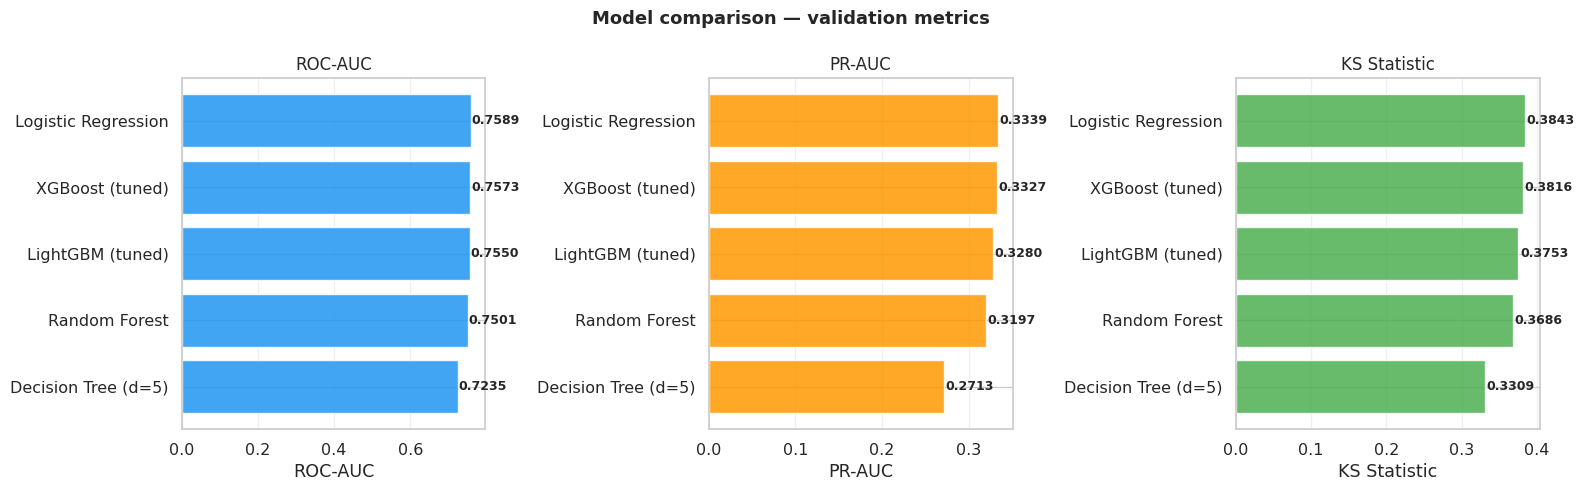

In [11]:
results_df = pd.DataFrame(results).sort_values('val_pr_auc', ascending=False)

print('=== MODEL COMPARISON TABLE ===')
print()
print(f'{"Model":<27} {"TrainAUC":>9} {"ValAUC":>8} {"PR-AUC":>8}'
      f' {"KS":>6} {"F1":>6} {"Overfit":>8}')
print('-' * 75)
for _, row in results_df.iterrows():
    overfit_flag = '  ***' if row['overfit_gap'] > 0.05 else ''
    print(f"{row['model']:<27} {row['train_auc']:>9.4f} {row['val_auc']:>8.4f} "
          f"{row['val_pr_auc']:>8.4f} {row['val_ks']:>6.4f} "
          f"{row['val_f1']:>6.4f} {row['overfit_gap']:>+8.4f}{overfit_flag}")

print()
champion = results_df.iloc[0]['model']
print(f'Champion model: {champion}')
print(f'  Val PR-AUC  : {results_df.iloc[0]["val_pr_auc"]:.4f}')
print(f'  Val AUC     : {results_df.iloc[0]["val_auc"]:.4f}')
print(f'  KS Statistic: {results_df.iloc[0]["val_ks"]:.4f}')
print(f'  Opt threshold: {results_df.iloc[0]["opt_threshold"]:.4f}')

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model comparison — validation metrics', fontsize=13, fontweight='bold')

metric_sets = [
    ('val_auc',    'ROC-AUC',    axes[0], '#2196F3'),
    ('val_pr_auc', 'PR-AUC',     axes[1], '#FF9800'),
    ('val_ks',     'KS Statistic', axes[2], '#4CAF50'),
]
for col, label, ax, color in metric_sets:
    ordered = results_df.sort_values(col, ascending=True)
    bars = ax.barh(ordered['model'], ordered[col],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(label)
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, ordered[col]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Precision-Recall Curves


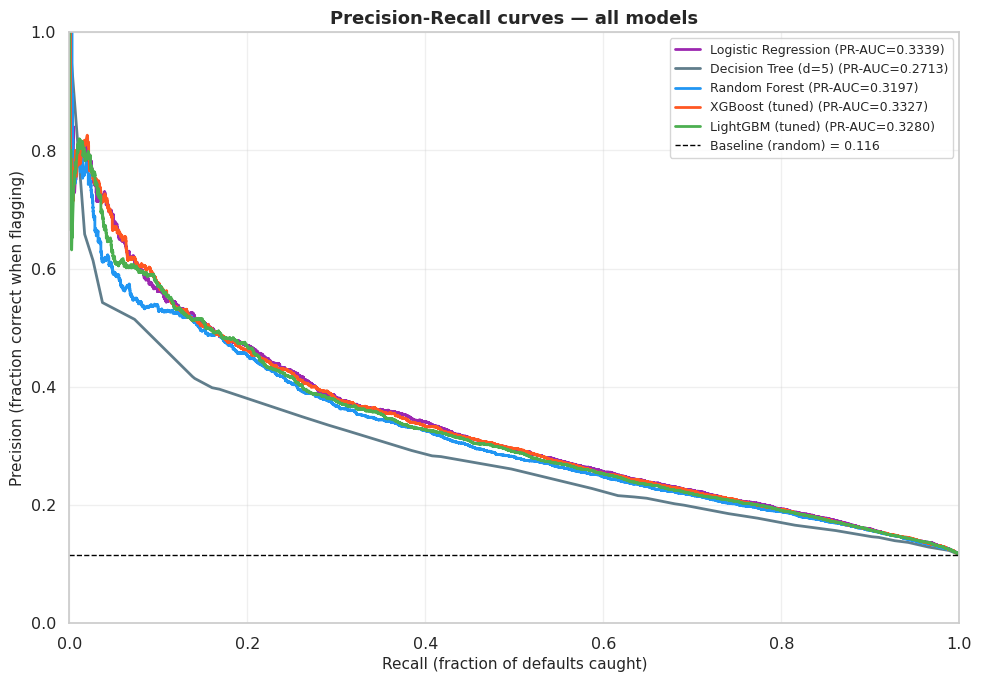

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
baseline_precision = y_val.mean()

model_colors = {
    'Logistic Regression': '#9C27B0',
    'Decision Tree (d=5)': '#607D8B',
    'Random Forest':       '#2196F3',
    'XGBoost (tuned)':     '#FF5722',
    'LightGBM (tuned)':    '#4CAF50',
}

for model_name, y_prob in val_probs.items():
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)
    ax.plot(recall, precision,
            color=model_colors.get(model_name, 'gray'),
            linewidth=2,
            label=f'{model_name} (PR-AUC={pr_auc:.4f})')

ax.axhline(baseline_precision, color='black', linestyle='--',
           linewidth=1, label=f'Baseline (random) = {baseline_precision:.3f}')
ax.set_xlabel('Recall (fraction of defaults caught)', fontsize=11)
ax.set_ylabel('Precision (fraction correct when flagging)', fontsize=11)
ax.set_title('Precision-Recall curves — all models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ROC Curves

### Reading the ROC curve

The ROC curve plots True Positive Rate (recall) against False Positive Rate (1-specificity) at every threshold. The diagonal line represents a random classifier — a model that has no predictive power. The further the curve bows toward the top-left corner, the better.

AUC = 0.5 → random  
AUC = 0.7 → acceptable  
AUC = 0.8 → good  
AUC = 0.9 → excellent  
AUC = 1.0 → perfect (suspicious — check for data leakage)

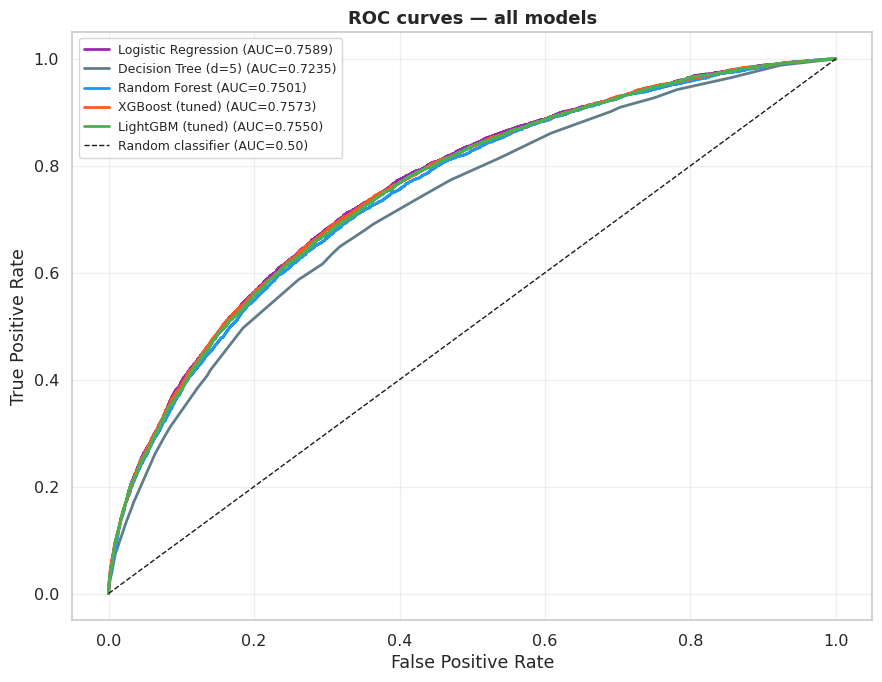

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

for model_name, y_prob in val_probs.items():
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score   = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr,
            color=model_colors.get(model_name, 'gray'),
            linewidth=2,
            label=f'{model_name} (AUC={auc_score:.4f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — all models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Threshold Optimization for Champion Model


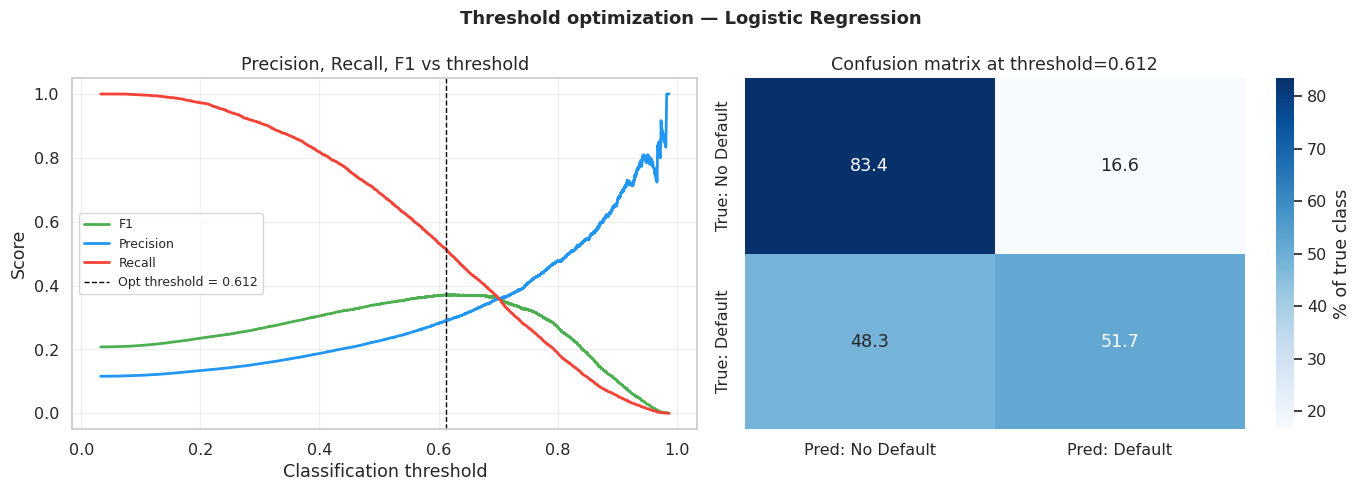


At optimal threshold = 0.6117:
  True Positives  (caught defaults)     :  2,298
  False Negatives (missed defaults)     :  2,150
  False Positives (wrongly rejected)    :  5,617
  True Negatives  (correct approvals)   : 28,237
  Precision  : 0.2903
  Recall     : 0.5166
  F1         : 0.3718


In [14]:
champion_name = results_df.iloc[0]['model']
champion_prob = val_probs[champion_name]
champion_model = models[champion_name]

precision_arr, recall_arr, thresholds = precision_recall_curve(y_val, champion_prob)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Threshold optimization — {champion_name}',
             fontsize=13, fontweight='bold')

# F1 vs threshold
best_f1_idx = np.argmax(f1_arr[:-1])
opt_thresh  = thresholds[best_f1_idx]
axes[0].plot(thresholds, f1_arr[:-1],    color='#4CAF50', linewidth=2, label='F1')
axes[0].plot(thresholds, precision_arr[:-1], color='#2196F3', linewidth=2, label='Precision')
axes[0].plot(thresholds, recall_arr[:-1],    color='#F44336', linewidth=2, label='Recall')
axes[0].axvline(opt_thresh, color='black', linestyle='--', linewidth=1,
                label=f'Opt threshold = {opt_thresh:.3f}')
axes[0].set_xlabel('Classification threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall, F1 vs threshold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Confusion matrix at optimal threshold
y_pred_opt = (champion_prob >= opt_thresh).astype(int)
cm = confusion_matrix(y_val, y_pred_opt)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: No Default','Pred: Default'],
            yticklabels=['True: No Default','True: Default'],
            cbar_kws={'label':'% of true class'})
axes[1].set_title(f'Confusion matrix at threshold={opt_thresh:.3f}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nAt optimal threshold = {opt_thresh:.4f}:')
print(f'  True Positives  (caught defaults)     : {tp:>6,}')
print(f'  False Negatives (missed defaults)     : {fn:>6,}')
print(f'  False Positives (wrongly rejected)    : {fp:>6,}')
print(f'  True Negatives  (correct approvals)   : {tn:>6,}')
print(f'  Precision  : {tp/(tp+fp):.4f}')
print(f'  Recall     : {tp/(tp+fn):.4f}')
print(f'  F1         : {2*tp/(2*tp+fp+fn):.4f}')

---
##  Feature Importance (Champion Model)


In [15]:
if hasattr(champion_model, 'feature_importances_'):
    if hasattr(champion_model, 'booster_'):
        # LightGBM
        imp_type = 'gain'
        importance_vals = champion_model.booster_.feature_importance(importance_type=imp_type)
    else:
        # XGBoost or Random Forest
        try:
            scores = champion_model.get_booster().get_score(importance_type='gain')
            importance_vals = np.array([scores.get(f, 0) for f in FEAT_COLS])
            imp_type = 'gain'
        except Exception:
            importance_vals = champion_model.feature_importances_
            imp_type = 'split'

    feat_imp = pd.Series(importance_vals, index=FEAT_COLS)
    feat_imp = feat_imp / feat_imp.sum()
    feat_imp = feat_imp.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#FF9800' if any(x in f for x in
              ['loan_to_income','interest_burden','monthly_payment',
               'employment_stability','age_risk_segment'])
              else '#2196F3' for f in feat_imp.index]
    ax.barh(range(len(feat_imp)), feat_imp.values,
            color=colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(feat_imp)))
    ax.set_yticklabels(feat_imp.index, fontsize=9)
    ax.set_xlabel(f'Normalized importance ({imp_type})')
    ax.set_title(f'Top 20 features — {champion_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#2196F3', label='Raw feature'),
                       Patch(color='#FF9800', label='Engineered feature')],
              fontsize=9, loc='lower right')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    engineered_importance = feat_imp[[f for f in feat_imp.index
                                      if any(x in f for x in
                                      ['loan_to_income','interest_burden',
                                       'monthly_payment','employment_stability',
                                       'age_risk_segment'])]].sum()
    print(f'\nEngineered features contribution: {engineered_importance*100:.1f}% of total importance')

---
##  KS Plot (Credit Industry Standard)

### What the KS plot shows

The KS plot displays two cumulative distribution functions on the same chart:
- The CDF of predicted scores for actual defaulters (red line)
- The CDF of predicted scores for actual non-defaulters (green line)

A perfect model would have complete separation — all defaulters at score 1.0, all non-defaulters at score 0.0. The KS statistic is the maximum vertical distance between the two curves.

In credit risk, the KS score is presented at monthly model monitoring meetings. A KS > 0.3 means the model is meaningfully separating good and bad borrowers. A declining KS over time signals model degradation and triggers retraining.

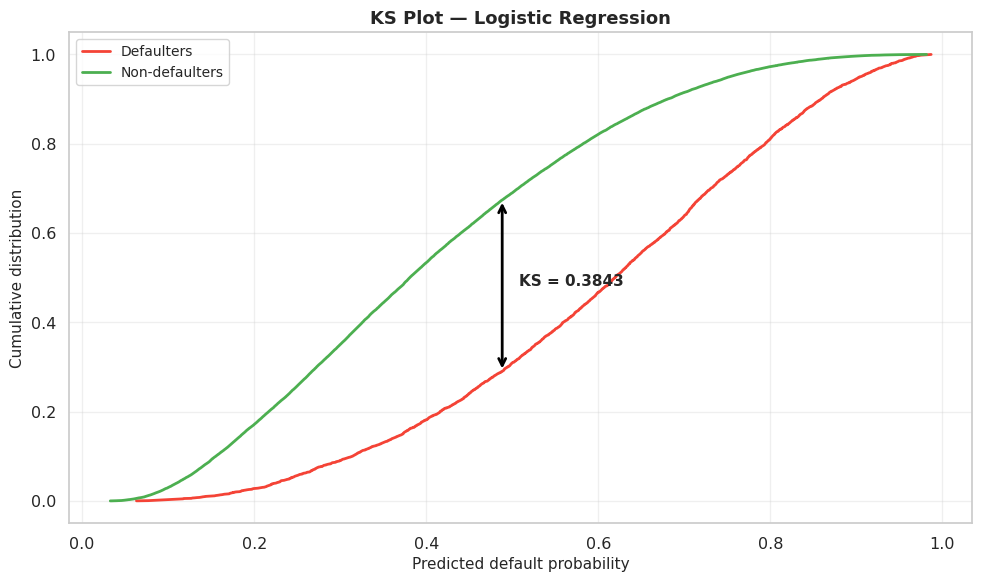

KS Statistic: 0.3843
Rating: Acceptable


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

default_scores     = champion_prob[y_val == 1]
no_default_scores  = champion_prob[y_val == 0]

sorted_def    = np.sort(default_scores)
sorted_nodef  = np.sort(no_default_scores)
cdf_def   = np.arange(1, len(sorted_def)+1)   / len(sorted_def)
cdf_nodef = np.arange(1, len(sorted_nodef)+1) / len(sorted_nodef)

ax.plot(sorted_def,   cdf_def,   color='#F44336', linewidth=2, label='Defaulters')
ax.plot(sorted_nodef, cdf_nodef, color='#4CAF50', linewidth=2, label='Non-defaulters')

# Find and annotate KS point
ks_val = ks_statistic(y_val, champion_prob)
all_scores = np.sort(np.concatenate([sorted_def, sorted_nodef]))
def_interp   = np.interp(all_scores, sorted_def,   cdf_def)
nodef_interp = np.interp(all_scores, sorted_nodef, cdf_nodef)
ks_idx  = np.argmax(np.abs(def_interp - nodef_interp))
ks_x    = all_scores[ks_idx]
ks_def  = def_interp[ks_idx]
ks_nodef = nodef_interp[ks_idx]

ax.annotate('', xy=(ks_x, ks_def), xytext=(ks_x, ks_nodef),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(ks_x + 0.02, (ks_def + ks_nodef)/2,
        f'KS = {ks_val:.4f}', fontsize=11, fontweight='bold')

ax.set_xlabel('Predicted default probability', fontsize=11)
ax.set_ylabel('Cumulative distribution', fontsize=11)
ax.set_title(f'KS Plot — {champion_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ks_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'KS Statistic: {ks_val:.4f}')
ks_rating = "Excellent" if ks_val > 0.5 else "Good" if ks_val > 0.4 else "Acceptable" if ks_val > 0.3 else "Needs improvement"
print(f'Rating: {ks_rating}')

---
##  Save Champion Model and Results

### What we save for Task 4

Task 4 needs:
1. The champion model — to generate predictions on the sealed test set
2. The optimal threshold — to convert probabilities to binary decisions
3. The full results table — to include in the final report
4. All trained models — for SHAP explainability analysis

In [17]:
# Save champion model
champion_model_obj = models[champion_name]
with open(OUTPUT_DIR / 'champion_model.pkl', 'wb') as f:
    pickle.dump(champion_model_obj, f)

# Save all models
with open(OUTPUT_DIR / 'all_models.pkl', 'wb') as f:
    pickle.dump(models, f)

# Save results table
results_df.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)

# Save optimal threshold
opt_thresh_final = float(results_df.iloc[0]['opt_threshold'])
with open(OUTPUT_DIR / 'champion_threshold.txt', 'w') as f:
    f.write(str(opt_thresh_final))

# Save val probabilities for all models
import json
val_probs_serializable = {k: v.tolist() for k, v in val_probs.items()}
with open(OUTPUT_DIR / 'val_probs.json', 'w') as f:
    json.dump(val_probs_serializable, f)

print('=== TASK 3 COMPLETE ===')
print()
print(f'Champion model      : {champion_name}')
print(f'Val ROC-AUC         : {results_df.iloc[0]["val_auc"]:.4f}')
print(f'Val PR-AUC          : {results_df.iloc[0]["val_pr_auc"]:.4f}')
print(f'Val KS Statistic    : {results_df.iloc[0]["val_ks"]:.4f}')
print(f'Val F1 (opt thresh) : {results_df.iloc[0]["val_f1"]:.4f}')
print(f'Optimal threshold   : {opt_thresh_final:.4f}')
print()
print('Files saved:')
for fname in ['champion_model.pkl', 'all_models.pkl',
              'model_results.csv', 'champion_threshold.txt',
              'val_probs.json']:
    size = (OUTPUT_DIR / fname).stat().st_size / 1024
    print(f'  {fname:<35} {size:>8.1f} KB')
print()
print('Pass champion_model.pkl and champion_threshold.txt to Task 4.')
print('Unseal X_test.csv / y_test.csv in Task 4 for final evaluation.')

=== TASK 3 COMPLETE ===

Champion model      : Logistic Regression
Val ROC-AUC         : 0.7589
Val PR-AUC          : 0.3339
Val KS Statistic    : 0.3843
Val F1 (opt thresh) : 0.3718
Optimal threshold   : 0.6117

Files saved:
  champion_model.pkl                       1.7 KB
  all_models.pkl                       34928.3 KB
  model_results.csv                        0.5 KB
  champion_threshold.txt                   0.0 KB
  val_probs.json                        3795.5 KB

Pass champion_model.pkl and champion_threshold.txt to Task 4.
Unseal X_test.csv / y_test.csv in Task 4 for final evaluation.


---
## What Task 3 Produced

### Model hierarchy (expected order best → worst)
1. XGBoost (tuned) or LightGBM (tuned) — sequential boosting with tuned hyperparameters
2. Random Forest — bagging ensemble, robust but less precise
3. Logistic Regression — linear baseline, interpretable
4. Decision Tree (d=5) — shallow, visual, underfits

### Key metrics for the final report
- **Baseline accuracy** (predict majority): 88.4%
- **LR ROC-AUC**: establishes linear model ceiling
- **Champion ROC-AUC**: improvement from non-linear modeling
- **Champion KS Statistic**: the credit industry metric

### What Task 4 does with these results
- Opens the sealed test set and computes final metrics
- Runs SHAP explainability on the champion model
- Generates the local explanation for a single rejected loan application
- Writes the model card documenting capabilities and limitations
